---
---
---

# Summary

---
---
---

<br>

## Dependencies

### Packages

In [1]:
from IPython.display import Image, display
from google.cloud import bigquery
from paddleocr import TextRecognition
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import paddle
import shutil
import sys
import warnings

ROOT_PATH = Path.cwd().resolve()
if ROOT_PATH.name == "notebook":
    ROOT_PATH = ROOT_PATH.parent
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))

from jobs.data_extract import extract_data
from lib import config as the_config
from lib import utils as the_utils

the_config.refresh_logging()

# -------------------------

%matplotlib inline
paddle.disable_signal_handler()
warnings.filterwarnings("ignore")

/Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


### Paths

In [2]:
for path in the_config.PATHS:
    the_utils.ensure_path(path)

## ETL Pipeline

### Extraction

In [3]:
extract_data(n=1)

2026-07-27 14:03:25.056 | INFO     | jobs.data_extract:extract_data:28 - 

# =========================
# (1) EXTRACTION
# =========================

2026-07-27 14:03:25.057 | DEBUG    | jobs.data_extract:extract_data:60 - [2026-07-27 @ 14:03] [01/19]
2026-07-27 14:03:25.057 | DEBUG    | jobs.data_extract:extract_data:61 - [2026-07-27 @ 14:03] STATION: Bellagio
2026-07-27 14:03:25.105 | SUCCESS  | jobs.data_extract:extract_data:88 - [2026-07-27 @ 14:03] EXTRACTED: bellagio_cernobbio-20260727-1403.png



{'bellagio_cernobbio': {'city': 'Bellagio',
  'province': 'Como',
  'lat': 45.9872549,
  'lon': 9.2613001,
  'elevation_m': 685}}

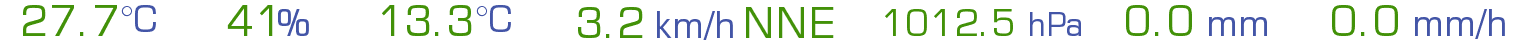

In [4]:
files = list(the_config.TMP_IMG_PATH.iterdir())
filename = files[0]
display(Image(filename=str(filename)))

### Transformation

In [5]:
# [!]
img_cv = cv2.imread(str(filename))
img_cv = cv2.resize(
    img_cv,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)

hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)
green_mask = cv2.inRange(
    hsv,
    np.array([35, 50, 50]),
    np.array([85, 255, 255]),
)
green = np.full_like(green_mask, 255)
green[green_mask > 0] = 0
blue_mask = cv2.inRange(
    hsv,
    np.array([90, 50, 50]),
    np.array([130, 255, 255]),
)
blue = np.full_like(blue_mask, 255)
blue[blue_mask > 0] = 0

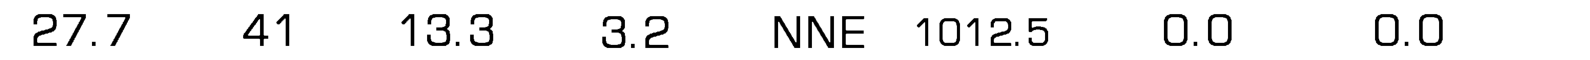

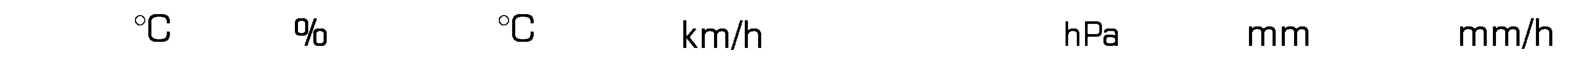

In [6]:
plt.figure(figsize=(16, 4))
plt.imshow(green, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.imshow(blue, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# [!]
green_rois = the_utils.extract_rois(img_cv, green_mask, "green")
blue_rois  = the_utils.extract_rois(img_cv, blue_mask, "blue")
all_rois = sorted(green_rois + blue_rois, key=lambda r: r["bbox"][0])

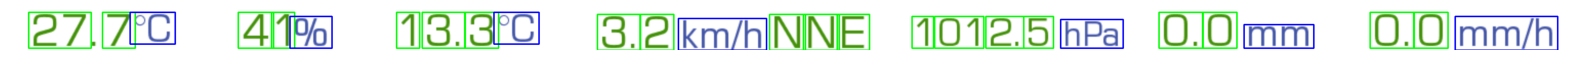

In [8]:
debug = img_cv.copy()
green_idx = 1
blue_idx = 1

for roi in all_rois:

    x1, y1, x2, y2 = roi["bbox"]
    if roi["type"] == "green":
        box_color = (0, 255, 0)
        letter = "G"
        idx = green_idx
        green_idx += 1
    else:
        box_color = (255, 0, 0)
        letter = "B"
        idx = blue_idx
        blue_idx += 1

    cv2.rectangle(debug, (x1, y1), (x2, y2), box_color, 2)
    (letter_w, letter_h), _ = cv2.getTextSize(
		letter,
		cv2.FONT_HERSHEY_SIMPLEX,
		1.4,
		3
	)
    (label_w, label_h), baseline = cv2.getTextSize(
		f"{letter}{idx}",
		cv2.FONT_HERSHEY_SIMPLEX,
		1.4,
		3
	)

plt.figure(figsize=(16, 4))
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# [!]
pieces = the_utils.get_pieces(img_cv, green_mask, all_rois)

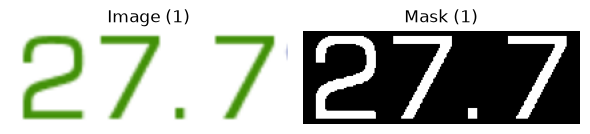

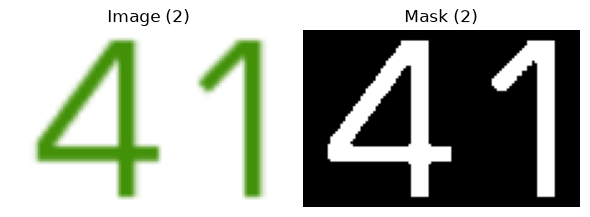

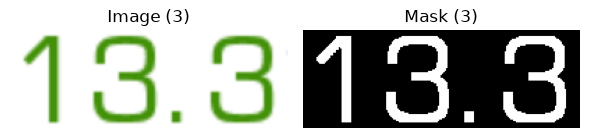

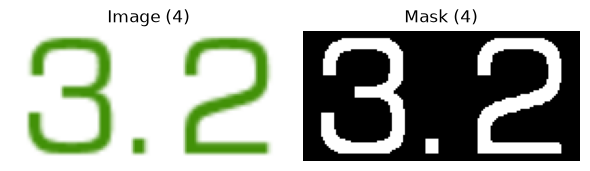

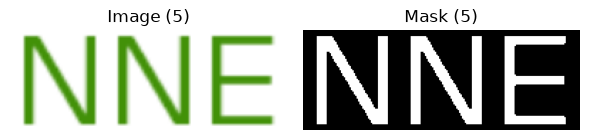

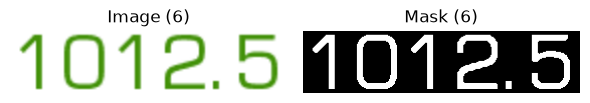

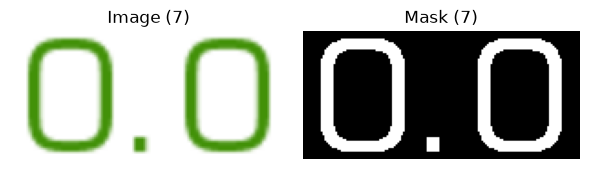

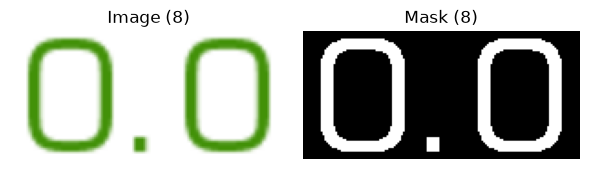

In [10]:
for i, piece in enumerate(pieces, start=1):

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))
    axes[0].imshow(cv2.cvtColor(piece["image"], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Image ({i})")
    axes[0].axis("off")
    axes[1].imshow(piece["green_mask"], cmap="gray")
    axes[1].set_title(f"Mask ({i})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [11]:
# [!]
MODEL_OCR = TextRecognition(
    model_name=the_config.OCR_MODEL,
    device=the_config.DEVICE
)

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/robertovicario/.paddlex/official_models/PP-OCRv5_server_rec`.


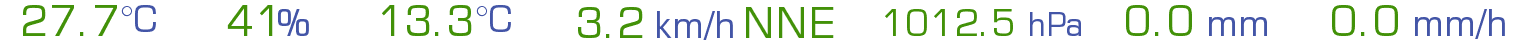

2026-07-27 14:03:26.149 | DEBUG    | lib.utils:ocr_predict:165 -    temperature_c:  27.7 (confidence=1.000)
2026-07-27 14:03:26.220 | DEBUG    | lib.utils:ocr_predict:165 -     humidity_pct:    41 (confidence=0.999)
2026-07-27 14:03:26.293 | DEBUG    | lib.utils:ocr_predict:165 -      dew_point_c:  13.3 (confidence=1.000)
2026-07-27 14:03:26.363 | DEBUG    | lib.utils:ocr_predict:165 -         wind_kmh:   3.2 (confidence=0.999)
2026-07-27 14:03:26.431 | DEBUG    | lib.utils:ocr_predict:165 -         wind_dir:   NNE (confidence=0.999)
2026-07-27 14:03:26.499 | DEBUG    | lib.utils:ocr_predict:165 -     pressure_hpa:1012.5 (confidence=1.000)
2026-07-27 14:03:26.567 | DEBUG    | lib.utils:ocr_predict:165 -          rain_mm:   0.0 (confidence=0.991)
2026-07-27 14:03:26.634 | DEBUG    | lib.utils:ocr_predict:165 -         rain_mmh:   0.0 (confidence=0.991)


In [12]:
display(Image(filename))

# [!]
values = the_utils.ocr_predict(
    MODEL_OCR,
    the_config.OCR_FIELDS,
    pieces,
    verbose=True
)

### Loading

In [13]:
client_bq = bigquery.Client(project=the_config.GCP_PROJECT)
query = f"""
SELECT * FROM `{the_config.BQ_TABLE}`;
"""
df = client_bq.query(query).to_dataframe()
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   filename       19 non-null     str    
 1   date           19 non-null     dbdate 
 2   year           19 non-null     Int64  
 3   month          19 non-null     Int64  
 4   day            19 non-null     Int64  
 5   hour           19 non-null     Int64  
 6   minute         19 non-null     Int64  
 7   station        19 non-null     str    
 8   city           19 non-null     str    
 9   province       19 non-null     str    
 10  lat            19 non-null     float64
 11  lon            19 non-null     float64
 12  elevation_m    19 non-null     float64
 13  temperature_c  19 non-null     float64
 14  humidity_pct   19 non-null     Int64  
 15  dew_point_c    19 non-null     float64
 16  wind_kmh       19 non-null     float64
 17  wind_dir       19 non-null     str    
 18  pressure_hpa   19 non-n

None

In [14]:
# [!]
shutil.rmtree(the_config.TMP_IMG_PATH)